<a href="https://colab.research.google.com/github/aguscgonzalez/analisis-radares-viales/blob/main/analisis_radares_viales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Flow — Análisis de Infracciones de Tránsito

## Descripción
Análisis y depuración de un dataset de infracciones por exceso
de velocidad en Vaalserberg, Bélgica. El proceso incluye limpieza
de datos, normalización, análisis estadístico y visualización.

## Tecnologías utilizadas
- Python
- Pandas
- Matplotlib
- Expresiones regulares (re)

## Dataset
4000 registros históricos de multas por exceso de velocidad,
reducidos a 1713 registros válidos tras el proceso de limpieza.

In [1]:
# Importación de librerías
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Creación de la estructura de directorios
os.chdir("/content")
os.makedirs("urban_flow/data/raw", exist_ok=True)
os.makedirs("urban_flow/data/interim/plots", exist_ok=True)
os.makedirs("urban_flow/data/processed", exist_ok=True)

In [2]:
# @title Descarga del dataset

url = (
  "https://raw.githubusercontent.com/HAD141/datasets/"
  "refs/heads/main/TrabajosPracticos/urban_flow/speeding_fines.csv"
)

df = pd.read_csv(url)
df.to_csv('/content/urban_flow/data/raw/speeding_fines.csv', index=False)

print(f"Dataset descargado: {len(df)} registros")

Dataset descargado: 4000 registros


In [3]:
# @title Exploración inicial del dataset

df.head()

,multa_id,patente,fecha,hora,velocidad_registrada,velocidad_maxima,ubicacion,radar_id,estado_multa
0,1,FD 1475,24/09/2021,09:01 AM,NaN,60,Av. Siempre Viva,R01,APELADA
1,2,0695 DVH,19/05/2020,18:01,NaN,40,Av Siempre Viva,NaN,APELADA
2,3,WU 341 A,2022/07/17,09:01 AM,107.0,60,AV LIBERTADOR,R03,PAGADA
3,4,GN64 OTP,invalid_date,invalid_hour,NaN,60,Ruta 9,NaN,APELADA
4,5,BX 55 DOG,2021/01/21,invalid_hour,94.0,60,Av. Siempre Viva,NaN,ERROR


In [4]:
# @title Tipos de datos y valores nulos

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   multa_id              4000 non-null   int64  
 1   patente               3950 non-null   object 
 2   fecha                 4000 non-null   object 
 3   hora                  4000 non-null   object 
 4   velocidad_registrada  2043 non-null   float64
 5   velocidad_maxima      4000 non-null   int64  
 6   ubicacion             4000 non-null   object 
 7   radar_id              2998 non-null   object 
 8   estado_multa          4000 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 281.4+ KB


,0
multa_id,0
patente,50
fecha,0
hora,0
velocidad_registrada,1957
velocidad_maxima,0
ubicacion,0
radar_id,1002
estado_multa,0


In [5]:
# @title Normalización de fechas

def normalizar_fecha(fecha):
  """Normaliza una fecha al formato YYYY-MM-DD.
  En caso de fecha inválida retorna 1932-01-01.
  """
  try:
    return pd.to_datetime(fecha, dayfirst=True).strftime('%Y-%m-%d')
  except:
    return '1932-01-01'

df['fecha'] = df['fecha'].apply(normalizar_fecha)
df['fecha'].head(10)

/tmp/ipykernel_11487/3258118138.py:8: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(fecha, dayfirst=True).strftime('%Y-%m-%d')
/tmp/ipykernel_11487/3258118138.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(fecha, dayfirst=True).strftime('%Y-%m-%d')


,fecha
0,2021-09-24
1,2020-05-19
2,2022-07-17
3,1932-01-01
4,2021-01-21
5,2023-07-27
6,2023-06-16
7,2023-11-01
8,1932-01-01
9,1932-01-01


In [6]:
# @title Normalización de horas

def normalizar_hora(hora):
  """Normaliza una hora al formato HH:MM en 24hs.
  En caso de hora inválida retorna 00:00.
  """
  try:
    return pd.to_datetime(hora, format='%H:%M').strftime('%H:%M')
  except:
    try:
      return pd.to_datetime(hora, format='%I:%M %p').strftime('%H:%M')
    except:
      return '00:00'

df['hora'] = df['hora'].apply(normalizar_hora)
df['hora'].head(10)

,hora
0,09:01
1,18:01
2,09:01
3,00:00
4,00:00
5,00:00
6,18:01
7,08:01
8,09:01
9,14:01


In [7]:
# @title Normalización de ubicaciones

def normalizar_ubicacion(ubicacion):
  """Elimina caracteres especiales y convierte a mayúsculas."""
  ubicacion = re.sub(r'[^a-zA-Z0-9\s]', '', str(ubicacion))
  return ubicacion.upper().strip()

df['ubicacion'] = df['ubicacion'].apply(normalizar_ubicacion)
df['ubicacion'].head(10)

,ubicacion
0,AV SIEMPRE VIVA
1,AV SIEMPRE VIVA
2,AV LIBERTADOR
3,RUTA 9
4,AV SIEMPRE VIVA
5,AV SIEMPRE VIVA
6,AV LIBERTADOR
7,AV SIEMPRE VIVA
8,AV SIEMPRE VIVA
9,AV LIBERTADOR


In [8]:
# @title Normalización de patentes

def normalizar_patente(patente):
  """Elimina caracteres especiales y convierte a mayúsculas.
  En caso de patente inválida retorna pd.NA.
  """
  try:
    patente = re.sub(r'[^a-zA-Z0-9]', '', str(patente))
    patente = patente.upper().strip()
    if patente == '' or patente == 'NAN':
      return pd.NA
    return patente
  except:
    return pd.NA

df['patente'] = df['patente'].apply(normalizar_patente)
df['patente'].tail(10)

,patente
3990,NHZ1002
3991,MX60NZA
3992,831MDB
3993,M20CPR
3994,BM351
3995,MPX9357
3996,831MDB
3997,BB8986
3998,8B90638
3999,691XC80


In [9]:
# @title Eliminación de registros con valores nulos relevantes

columnas_relevantes = ['velocidad_registrada', 'velocidad_maxima', 'patente']

filas_antes = len(df)
df = df.dropna(subset=columnas_relevantes)
filas_despues = len(df)

print(f"Se eliminaron {filas_antes - filas_despues} filas.")
print("Las columnas observadas son:")
for col in columnas_relevantes:
  print(f" - {col}")

Se eliminaron 1982 filas.
Las columnas observadas son:
 - velocidad_registrada
 - velocidad_maxima
 - patente


In [10]:
# @title Detección y eliminación de outliers

columnas_outliers = ['velocidad_registrada', 'velocidad_maxima']

filas_antes = len(df)

for col in columnas_outliers:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  df = df[
    (df[col] >= q1 - 1.5 * iqr) &
    (df[col] <= q3 + 1.5 * iqr)
  ]

filas_despues = len(df)

print(f"Se eliminaron {filas_antes - filas_despues} filas.")
print("Las columnas observadas son:")
for col in columnas_outliers:
  print(f" - {col}")

Se eliminaron 0 filas.
Las columnas observadas son:
 - velocidad_registrada
 - velocidad_maxima


In [11]:
# @title Cálculo de exceso de velocidad real

df['exceso_velocidad_real'] = (
  df['velocidad_registrada'] - df['velocidad_maxima']
)

df[['patente', 'exceso_velocidad_real']].head(10)

,patente,exceso_velocidad_real
2,WU341A,47.0
4,BX55DOG,34.0
7,BP717,10.0
9,OUTSTDN,31.0
11,TL03GOG,-2.0
12,GE1466,35.0
16,5777770,53.0
20,BHRP770,11.0
21,RFH373,41.0
23,XIIUME,12.0


In [12]:
# @title Cálculo de exceso de velocidad con margen del 5%

df['exceso_velocidad'] = (
  df['velocidad_registrada'] - (df['velocidad_maxima'] * 1.05)
)

df[['patente', 'exceso_velocidad']].head(10)

,patente,exceso_velocidad
2,WU341A,44.0
4,BX55DOG,31.0
7,BP717,7.0
9,OUTSTDN,29.0
11,TL03GOG,-4.0
12,GE1466,33.0
16,5777770,51.0
20,BHRP770,8.0
21,RFH373,37.0
23,XIIUME,10.0


In [13]:
# @title Eliminación de registros sin infracción

filas_antes = len(df)
df = df[df['exceso_velocidad'] > 0]
filas_despues = len(df)

print(f"Se eliminaron {filas_antes - filas_despues} filas.")

Se eliminaron 305 filas.


In [14]:
# @title Guardado del dataset limpio

df.to_csv(
  '/content/urban_flow/data/interim/speeding_fines.csv',
  index=False
)

print("Dataset limpio guardado en data/interim/speeding_fines.csv")
print(f"Registros finales: {len(df)}")

Dataset limpio guardado en data/interim/speeding_fines.csv
Registros finales: 1713


In [15]:
# @title Clase FineAnalyzer

class FineAnalyzer:
  """Clase para el análisis de infracciones de tránsito."""

  def __init__(self, dataframe):
    """Inicializa la clase con el DataFrame limpio."""
    self.__df = dataframe.copy()

  def ranking_patentes(self):
    """Retorna un DataFrame con el top 5 de patentes más multadas."""
    resultado = (
      self.__df.groupby('patente')
      .size()
      .reset_index(name='cantidad')
      .sort_values('cantidad', ascending=False)
      .head(5)
    )
    resultado.index = range(1, len(resultado) + 1)
    return resultado

  def ranking_horarios(self):
    """Retorna un DataFrame con el top 5 de horarios con más multas."""
    resultado = (
      self.__df.groupby('hora')
      .size()
      .reset_index(name='cantidad')
      .sort_values('cantidad', ascending=False)
      .head(5)
    )
    resultado.index = range(1, len(resultado) + 1)
    return resultado

  def exceso_promedio(self):
    """Retorna el exceso promedio de velocidad como flotante."""
    return float(self.__df['exceso_velocidad'].mean())

  def exceso_real_promedio(self):
    """Retorna el exceso real promedio de velocidad como flotante."""
    return float(self.__df['exceso_velocidad_real'].mean())

  def multas_por_ubicacion(self):
    """Retorna un DataFrame con la cantidad de multas por ubicación."""
    resultado = (
      self.__df.groupby('ubicacion')
      .size()
      .reset_index(name='cantidad')
      .sort_values('ubicacion')
    )
    return resultado

In [16]:
# @title Crear objeto FineAnalyzer

analyzer = FineAnalyzer(df)
print("Objeto FineAnalyzer creado correctamente.")

Objeto FineAnalyzer creado correctamente.


In [17]:
# @title Ranking de patentes más multadas

analyzer.ranking_patentes()

,patente,cantidad
1,WEFLYN,38
2,HF3461,37
3,T0YDR,36
4,M431ZW,34
5,AWS167,33


In [18]:
# @title Ranking de horarios con más multas

analyzer.ranking_horarios()

,hora,cantidad
1,00:00,339
2,09:04,9
3,09:20,8
4,09:23,8
5,10:38,8


In [19]:
# @title Exceso promedio de velocidad

analyzer.exceso_promedio()

39.318155283129016

In [20]:
# @title Exceso real promedio de velocidad

analyzer.exceso_real_promedio()

42.345008756567424

In [21]:
# @title Multas por ubicación

analyzer.multas_por_ubicacion()

,ubicacion,cantidad
0,AV LIBERTADOR,708
1,AV SIEMPRE VIVA,512
2,RUTA 9,493


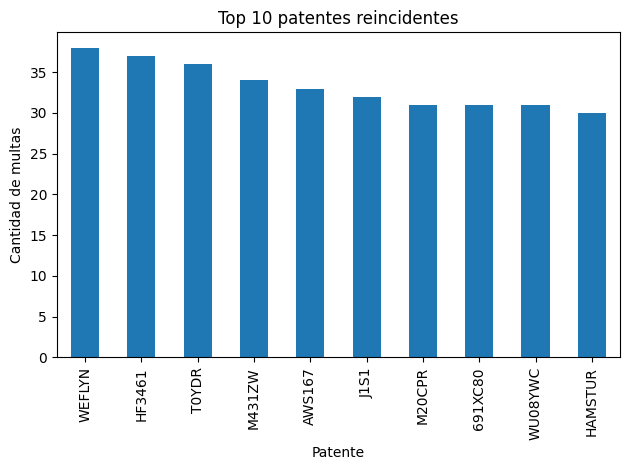

In [22]:
# @title Gráfico - Top 10 patentes reincidentes

top_patentes = (
  df.groupby('patente')
  .size()
  .reset_index(name='cantidad')
  .sort_values('cantidad', ascending=False)
  .head(10)
)

top_patentes.plot(
  kind='bar',
  x='patente',
  y='cantidad',
  title='Top 10 patentes reincidentes',
  xlabel='Patente',
  ylabel='Cantidad de multas',
  legend=False
)

plt.tight_layout()
plt.savefig('/content/urban_flow/data/interim/plots/fines.jpg')
plt.show()

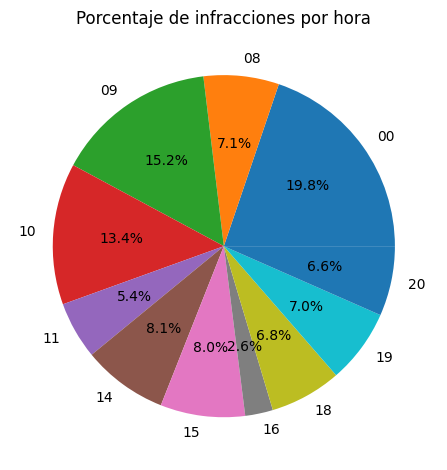

In [23]:
# @title Gráfico - Porcentaje de infracciones por hora

df['hora_entera'] = df['hora'].str.split(':').str[0]

por_hora = df.groupby('hora_entera').size()

por_hora.plot(
  kind='pie',
  title='Porcentaje de infracciones por hora',
  autopct='%1.1f%%',
  legend=False
)

plt.tight_layout()
plt.savefig('/content/urban_flow/data/interim/plots/hours.jpg')
plt.show()

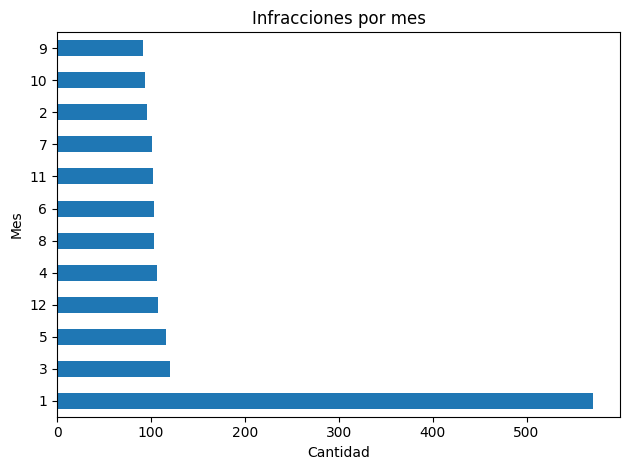

In [24]:
# @title Gráfico - Infracciones por mes

df['mes'] = pd.to_datetime(df['fecha']).dt.month

por_mes = (
  df.groupby('mes')
  .size()
  .reset_index(name='cantidad')
  .sort_values('cantidad', ascending=False)
)

por_mes.plot(
  kind='barh',
  x='mes',
  y='cantidad',
  title='Infracciones por mes',
  xlabel='Cantidad',
  ylabel='Mes',
  legend=False
)

plt.tight_layout()
plt.savefig('/content/urban_flow/data/interim/plots/months.jpg')
plt.show()

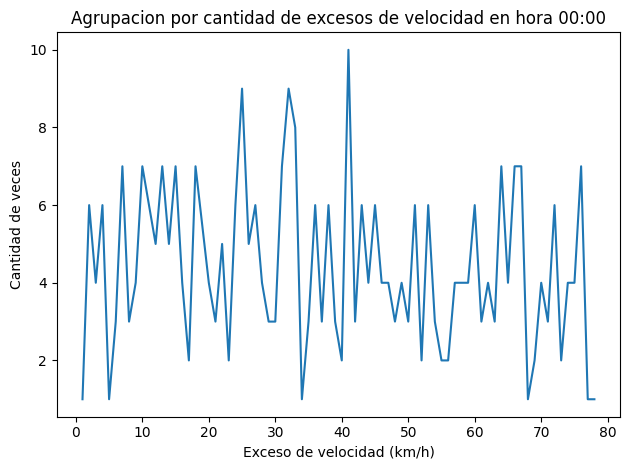

In [25]:
# @title Gráfico - Agrupación de excesos en hora 00:00

df_hora_00 = df[df['hora'] == '00:00']

por_exceso = (
  df_hora_00.groupby('exceso_velocidad')
  .size()
  .reset_index(name='cantidad')
)

por_exceso.plot(
  kind='line',
  x='exceso_velocidad',
  y='cantidad',
  title='Agrupacion por cantidad de excesos de velocidad en hora 00:00',
  xlabel='Exceso de velocidad (km/h)',
  ylabel='Cantidad de veces',
  legend=False
)

plt.tight_layout()
plt.savefig('/content/urban_flow/data/interim/plots/hour.jpg')
plt.show()

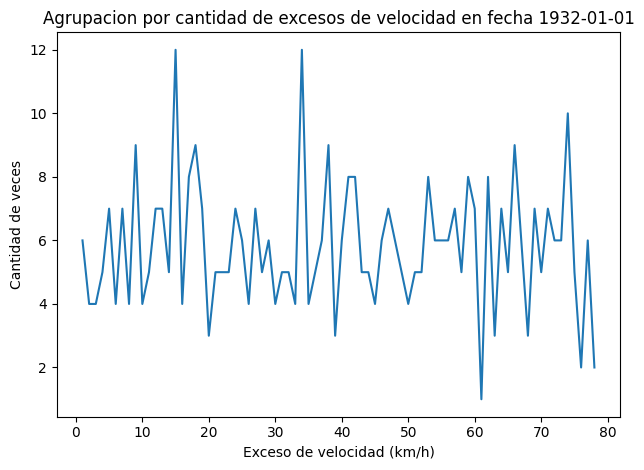

In [26]:
# @title Gráfico - Agrupación de excesos en fecha 1932-01-01

df_fecha_1932 = df[df['fecha'] == '1932-01-01']

por_exceso_fecha = (
  df_fecha_1932.groupby('exceso_velocidad')
  .size()
  .reset_index(name='cantidad')
)

por_exceso_fecha.plot(
  kind='line',
  x='exceso_velocidad',
  y='cantidad',
  title='Agrupacion por cantidad de excesos de velocidad en fecha 1932-01-01',
  xlabel='Exceso de velocidad (km/h)',
  ylabel='Cantidad de veces',
  legend=False
)

plt.tight_layout()
plt.savefig('/content/urban_flow/data/interim/plots/date.jpg')
plt.show()

In [27]:
# @title Análisis de registros con datos inválidos

total = len(df)
fecha_1932 = len(df[df['fecha'] == '1932-01-01'])
hora_00 = len(df[df['hora'] == '00:00'])

porcentaje_fecha = (fecha_1932 / total) * 100
porcentaje_hora = (hora_00 / total) * 100

print(f"El porcentaje de infracciones en la fecha 1932-01-01 es {porcentaje_fecha:.2f}%")
print(f"El porcentaje de infracciones a la hora 00:00 es {porcentaje_hora:.2f}%")

El porcentaje de infracciones en la fecha 1932-01-01 es 26.44%
El porcentaje de infracciones a la hora 00:00 es 19.79%


## Conclusión

1. **Calidad de datos**: El dataset original presentaba numerosas inconsistencias:
   - 1982 filas con valores nulos en columnas relevantes
   - Formatos de fechas y horas inconsistentes
   - Caracteres especiales en ubicaciones y patentes

2. **Infracciones críticas**:
   - 26.44% de las infracciones tienen fecha inválida (1932-01-01)
   - 19.79% ocurren a las 00:00 horas
   - Esto sugiere problemas en el registro del sistema heredado

3. **Comportamiento**:
   - El exceso de velocidad promedio real es de 42.35 km/h
   - El exceso considerando el margen del 5% es de 39.32 km/h
   - Esto indica que los conductores exceden significativamente los límites

4. **Recomendaciones**:
   - Implementar validaciones en el nuevo sistema para evitar fechas/horas inválidas
   - Revisar los radares que operan a las 00:00 horas
   - Considerar aumentar controles en las ubicaciones más conflictivas:
     AV LIBERTADOR, AV SIEMPRE VIVA, RUTA 9